# ShopEase Europe - Notebook 11: Deployment and Monitoring
**Project:** Sentiment Analysis for Customer Feedback
**Stage:** Deployment (Section 13) + Monitoring (Section 14)
**Dataset:** amazon_reviews_cleaned.csv

This notebook covers the final two sections of the project brief:

**Section 13 - Deployment:**
- Real-time sentiment prediction on new reviews
- Topic extraction for incoming reviews
- Automated summary generation pipeline
- Streamlit application overview

**Section 14 - Monitoring and Continuous Improvement:**
- Model performance tracking over time
- Data drift detection
- Sentiment drift analysis
- Scheduled retraining framework

In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn evidently --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 11.1 Load Libraries and Data

In [2]:
import re, pickle, os, warnings, random, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.ticker as mticker
import seaborn as sns
warnings.filterwarnings('ignore')
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
for pkg in ['punkt','stopwords','wordnet','punkt_tab','omw-1.4']:
    nltk.download(pkg, quiet=True)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
PALETTE = {'Positive': '#2ecc71', 'Neutral': '#3498db', 'Negative': '#e74c3c'}
COUNTRY_NAMES = {
    'US': 'United States', 'GB': 'United Kingdom', 'CA': 'Canada',
    'IN': 'India', 'IE': 'Ireland', 'DK': 'Denmark', 'NL': 'Netherlands',
    'AU': 'Australia', 'DE': 'Germany', 'IT': 'Italy', 'FR': 'France',
    'SE': 'Sweden', 'ES': 'Spain', 'AE': 'United Arab Emirates'
}

df = pd.read_csv(r'C:\Users\ifech\OneDrive\Desktop\sentiment_analysis\data\processed\amazon_reviews_cleaned_processed.csv')
df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
for col in ['sentiment','country','product_category']:
    df[col] = df[col].str.strip()
df['sentiment'] = df['sentiment'].str.capitalize()
df['timestamp'] = pd.to_datetime(df['timestamp'], format='ISO8601', utc=True)
df['year']       = df['timestamp'].dt.year
df['month']      = df['timestamp'].dt.month
df['year_month'] = df['timestamp'].dt.to_period('M').astype(str)
df = df.dropna(subset=['country']).reset_index(drop=True)
df = df.drop_duplicates(subset='review', keep='first').reset_index(drop=True)

lemmatizer = WordNetLemmatizer()
STOPS = set(stopwords.words('english')) | {
    'product','item','ordered','order','amazon','purchase',
    'bought','buy','would','also','one','get','got','use',
    'used','using','review','star','stars','rating'}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'https?\S+|www\.\S+', ' ', text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = word_tokenize(text)
    return ' '.join([lemmatizer.lemmatize(t) for t in tokens if t not in STOPS and len(t) > 2])

df['clean_review'] = df['review'].apply(clean_text)
print(f"Dataset ready: {len(df):,} rows")

Dataset ready: 20,406 rows


## 11.2 Train and Save Pipeline

In [3]:
le = LabelEncoder()
y  = le.fit_transform(df['sentiment'])

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['clean_review'], y, test_size=0.20, random_state=42, stratify=y)

tfidf = TfidfVectorizer(max_features=20_000, ngram_range=(1,2),
    sublinear_tf=True, min_df=3, max_df=0.90)
X_train = tfidf.fit_transform(X_train_raw)
X_test  = tfidf.transform(X_test_raw)

lr = LogisticRegression(max_iter=1000, C=5, class_weight='balanced', random_state=42)
lr.fit(X_train, y_train)

os.makedirs('../models', exist_ok=True)
with open('../models/tfidf_vectoriser.pkl', 'wb') as f: pickle.dump(tfidf, f)
with open('../models/label_encoder.pkl',   'wb') as f: pickle.dump(le,    f)
with open('../models/logistic_regression.pkl', 'wb') as f: pickle.dump(lr, f)

baseline_f1  = f1_score(y_test, lr.predict(X_test), average='weighted', zero_division=0)
baseline_acc = accuracy_score(y_test, lr.predict(X_test))
print(f"Baseline F1 (test set): {baseline_f1:.4f}")
print(f"Baseline Accuracy     : {baseline_acc:.4f}")
print("Model artefacts saved to ../models/")

# Save baseline metrics for monitoring
metrics_log = [{
    'date': '2024-09-17',
    'model': 'LogisticRegression',
    'f1_weighted': round(baseline_f1, 4),
    'accuracy': round(baseline_acc, 4),
    'n_reviews': len(df),
    'negative_rate': round((df['sentiment']=='Negative').mean(), 4)
}]
with open('../models/metrics_log.json', 'w') as f:
    json.dump(metrics_log, f, indent=2)
print("Baseline metrics saved to ../models/metrics_log.json")

Baseline F1 (test set): 0.8841
Baseline Accuracy     : 0.8827
Model artefacts saved to ../models/
Baseline metrics saved to ../models/metrics_log.json


> **Interpretation - Pipeline Serialisation**
>
> All three artefacts are saved separately so each can be updated independently in production. The TF-IDF vectoriser defines the feature vocabulary and must be retrained whenever the vocabulary needs to expand. The label encoder maps numeric class indices to sentiment labels and rarely changes unless new sentiment classes are added. The classifier is the component most likely to need periodic retraining as customer language evolves. A baseline metrics log is written at training time so the monitoring system has a reference point for detecting performance degradation.

## 11.3 Real-Time Prediction Pipeline

In [4]:
def predict_review(raw_text, tfidf_vec, classifier, label_enc):
    cleaned = clean_text(raw_text)
    X       = tfidf_vec.transform([cleaned])
    pred_idx  = classifier.predict(X)[0]
    pred_prob = classifier.predict_proba(X)[0]
    label     = label_enc.inverse_transform([pred_idx])[0]
    probs     = {cls: round(float(p), 4)
                 for cls, p in zip(label_enc.classes_, pred_prob)}
    return {
        'label':         label,
        'confidence':    round(float(max(pred_prob)), 4),
        'probabilities': probs,
        'is_uncertain':  max(pred_prob) < 0.65
    }

# Test on sample reviews
test_cases = [
    "My account was frozen for two weeks and nobody could help me.",
    "Arrived the next day, exactly as described. Very happy with this purchase.",
    "Decent product, does what it says. Not the best but acceptable for the price.",
    "Waited six weeks for a refund. Complete nightmare dealing with customer service.",
    "Beautifully packaged, quality is excellent and delivery was super fast."
]

print("REAL-TIME PREDICTION DEMO")
print("=" * 65)
for review in test_cases:
    result = predict_review(review, tfidf, lr, le)
    flag   = " [UNCERTAIN - route to human review]" if result['is_uncertain'] else ""
    print(f"\nReview    : {review[:80]}...")
    print(f"Prediction: {result['label']}  (confidence: {result['confidence']:.2%}){flag}")
    for cls, prob in result['probabilities'].items():
        bar = '#' * int(prob * 30)
        print(f"  {cls:<10} {prob:.4f}  {bar}")

REAL-TIME PREDICTION DEMO

Review    : My account was frozen for two weeks and nobody could help me....
Prediction: Negative  (confidence: 83.98%)
  Negative   0.8398  #########################
  Neutral    0.0831  ##
  Positive   0.0771  ##

Review    : Arrived the next day, exactly as described. Very happy with this purchase....
Prediction: Positive  (confidence: 97.93%)
  Negative   0.0094  
  Neutral    0.0112  
  Positive   0.9793  #############################

Review    : Decent product, does what it says. Not the best but acceptable for the price....
Prediction: Positive  (confidence: 89.42%)
  Negative   0.0129  
  Neutral    0.0928  ##
  Positive   0.8942  ##########################

Review    : Waited six weeks for a refund. Complete nightmare dealing with customer service....
Prediction: Negative  (confidence: 91.72%)
  Negative   0.9172  ###########################
  Neutral    0.0251  
  Positive   0.0577  #

Review    : Beautifully packaged, quality is excellent and deli

> **Interpretation - Real-Time Prediction**
>
> The `predict_review` function is the core inference function used by the Streamlit application in `src/app.py`. It applies the same preprocessing pipeline as the training stage, transforms the cleaned text using the fitted TF-IDF vectoriser, and returns the predicted class with full probability scores. The `is_uncertain` flag triggers when no class exceeds 0.65 probability, identifying reviews where the model is genuinely ambiguous. In a production customer service workflow, uncertain predictions would be routed to a human reviewer rather than acted on automatically, which is the recommended triage strategy for maintaining quality without requiring human review of every prediction.

## 11.4 Topic Extraction on New Reviews

In [5]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import TfidfVectorizer as TV2
import numpy as np

# ── Safety check: fill any null clean_review values ──────────────────────────
df['clean_review'] = df['clean_review'].fillna('')

# ── Inspect topics BEFORE assigning labels ────────────────────────────────────
# Run this first to see the actual top words per topic, then update
# TOPIC_LABELS below based on what you see
TOPIC_LABELS = {
    0: 'Delivery and Shipping',
    1: 'Account and Billing',
    2: 'Product Quality',
    3: 'Customer Service',
    4: 'Returns and Refunds',
    5: 'Pricing and Value',
    6: 'Positive Experience'
}

# ── TF-IDF vectorisation ──────────────────────────────────────────────────────
# Reduced max_features and switched to unigrams to lower memory usage
tfidf_lda = TV2(
    max_features=2000,
    min_df=5,
    max_df=0.85,
    ngram_range=(1, 1)    # unigrams only to reduce memory
)
X_lda = tfidf_lda.fit_transform(df['clean_review'])

# ── LDA Model ─────────────────────────────────────────────────────────────────
# n_jobs=1 prevents the TerminatedWorkerError caused by parallel workers
# learning_method='batch' is more stable than 'online' on local machines
lda = LatentDirichletAllocation(
    n_components=7,
    random_state=42,
    max_iter=10,
    learning_method='batch',
    n_jobs=1
)
lda.fit(X_lda)
print("LDA model fitted successfully")

# ── Inspect topic words BEFORE trusting the labels ───────────────────────────
print()
print("TOP WORDS PER TOPIC - review these before confirming TOPIC_LABELS:")
print("=" * 65)
feature_names = tfidf_lda.get_feature_names_out()
for idx, topic in enumerate(lda.components_):
    top_words = [feature_names[i] for i in topic.argsort()[-10:]]
    print(f"Topic {idx}: {', '.join(top_words)}")

# ── Assign topics to full dataframe ───────────────────────────────────────────
df['dominant_topic'] = lda.transform(X_lda).argmax(axis=1)
df['topic_label']    = df['dominant_topic'].map(TOPIC_LABELS)

# ── Topic extraction function ─────────────────────────────────────────────────
def extract_topic(raw_text, tfidf_vec, lda_model, topic_labels):
    cleaned = clean_text(raw_text)
    X_vec   = tfidf_vec.transform([cleaned])
    probs   = lda_model.transform(X_vec)[0]
    top_idx = probs.argmax()
    return {
        'topic':      topic_labels.get(top_idx, f"Topic {top_idx}"),
        'confidence': round(float(probs.max()), 4),
        'all_topics': {
            topic_labels.get(i, f"Topic {i}"): round(float(p), 4)
            for i, p in enumerate(probs)
        }
    }

# ── Test on sample reviews ────────────────────────────────────────────────────
print()
print("TOPIC EXTRACTION ON NEW REVIEWS")
print("=" * 65)
for review in test_cases:
    sentiment = predict_review(review, tfidf, lr, le)['label']
    topic     = extract_topic(review, tfidf_lda, lda, TOPIC_LABELS)
    print(f"\nReview   : {review[:80]}...")
    print(f"Sentiment: {sentiment}")
    print(f"Topic    : {topic['topic']}  "
          f"(confidence: {topic['confidence']:.2%})")

# ── Topic volume summary ──────────────────────────────────────────────────────
print()
print("TOPIC VOLUME SUMMARY:")
print("-" * 45)
for topic, count in df['topic_label'].value_counts().items():
    print(f"  {topic:<30} {count:,}")

LDA model fitted successfully

TOP WORDS PER TOPIC - review these before confirming TOPIC_LABELS:
Topic 0: year, money, time, refund, company, return, review, service, customer, seller
Topic 1: service, week, late, date, next, delivered, time, prime, delivery, day
Topic 2: bank, phone, credit, email, gift, money, service, customer, card, account
Topic 3: door, time, refund, parcel, delivered, service, customer, package, driver, delivery
Topic 4: never, online, shopping, company, ever, worst, love, customer, service, best
Topic 5: love, easy, price, excellent, delivery, fast, service, good, always, great
Topic 6: find, item, like, shipping, book, good, free, product, prime, price

TOPIC EXTRACTION ON NEW REVIEWS

Review   : My account was frozen for two weeks and nobody could help me....
Sentiment: Negative
Topic    : Product Quality  (confidence: 74.58%)

Review   : Arrived the next day, exactly as described. Very happy with this purchase....
Sentiment: Positive
Topic    : Pricing and 

> **Interpretation - Topic Extraction**
>
> Topic extraction gives each incoming review a second label alongside its sentiment: what the customer is talking about, not just how they feel about it. A review flagged as Negative with topic "Account and Billing" should be routed to the account management team. A Negative review with topic "Delivery and Shipping" should go to the logistics team. Combining sentiment and topic at inference time converts each new review into a structured ticket with automatic triage, which is the core business value of the deployment pipeline.

## 11.5 Automated Summary Generation Pipeline

In [6]:
def generate_weekly_digest(df_week, tfidf_vec, classifier, label_enc,
                            tfidf_lda_vec, lda_model, topic_labels):
    results = []
    for _, row in df_week.iterrows():
        sentiment = predict_review(
            row['review'], tfidf_vec, classifier, label_enc)
        topic = extract_topic(
            row['review'], tfidf_lda_vec, lda_model, topic_labels)

        # Compute is_uncertain directly from confidence
        # instead of relying on predict_review to return it
        confidence = sentiment['confidence']
        is_uncertain = confidence < 0.65

        results.append({
            'review_id':  row.get('review_id', 'N/A'),
            'sentiment':  sentiment['label'],
            'confidence': round(float(confidence), 4),
            'topic':      topic['topic'],
            'uncertain':  is_uncertain
        })

    results_df = pd.DataFrame(results)

    total = len(results_df)
    n_neg = (results_df['sentiment'] == 'Negative').sum()
    n_pos = (results_df['sentiment'] == 'Positive').sum()
    n_unc = results_df['uncertain'].sum()

    digest = {
        'period':            'Weekly Digest',
        'total_reviews':     total,
        'negative_count':    int(n_neg),
        'negative_rate_pct': round(n_neg / total * 100, 1),
        'positive_count':    int(n_pos),
        'positive_rate_pct': round(n_pos / total * 100, 1),
        'uncertain_reviews': int(n_unc),
        'top_topics':        results_df['topic'].value_counts().head(3).to_dict(),
        'alert':             n_neg / total > 0.75
    }
    return digest, results_df

# Run on a sample batch of 100 new reviews
sample_batch = df.sample(100, random_state=99)
digest, batch_results = generate_weekly_digest(
    sample_batch, tfidf, lr, le, tfidf_lda, lda, TOPIC_LABELS)

print("AUTOMATED WEEKLY DIGEST")
print("=" * 50)
for k, v in digest.items():
    print(f"  {k:<25} {v}")

print()
print("ROUTING SUMMARY:")
print(batch_results.groupby(
    ['topic', 'sentiment']).size().unstack(fill_value=0).to_string())

if digest['alert']:
    print()
    print("*** ALERT: Negative rate exceeds 75% threshold — escalation recommended ***")

AUTOMATED WEEKLY DIGEST
  period                    Weekly Digest
  total_reviews             100
  negative_count            64
  negative_rate_pct         64.0
  positive_count            28
  positive_rate_pct         28.0
  uncertain_reviews         8
  top_topics                {'Customer Service': 20, 'Delivery and Shipping': 18, 'Product Quality': 17}
  alert                     False

ROUTING SUMMARY:
sentiment              Negative  Neutral  Positive
topic                                             
Account and Billing          10        1         0
Customer Service             17        1         2
Delivery and Shipping        12        3         3
Positive Experience           8        0         8
Pricing and Value             0        2        13
Product Quality              16        1         0
Returns and Refunds           1        0         2


> **Interpretation - Automated Weekly Digest**
>
> The weekly digest function encapsulates the full inference pipeline into a single callable that can be scheduled to run automatically on new review batches. It returns both a summary dictionary suitable for email or Slack notification and a detailed results dataframe for operational teams. The alert flag triggers when the negative rate exceeds a configurable threshold, which would fire a notification to the head of customer experience and the relevant department leads. In production, this function would be wrapped in an Apache Airflow DAG that runs every Monday morning on the previous week's reviews, distributing the digest and routing uncertain predictions to a human review queue.

## 11.6 Streamlit Application Overview

In [7]:
overview = [
    "The full Streamlit deployment application is at: src/app.py",
    "",
    "Features implemented in the Streamlit app:",
    "  - Single Review tab: paste any review, get instant sentiment prediction",
    "    with probability scores for all three classes",
    "  - Batch Upload tab: upload a CSV with a 'review' column and download",
    "    predictions with confidence scores appended",
    "  - About tab: model summary, limitations, and pipeline description",
    "",
    "To launch the app:",
    "  1. Run Notebook 7 to generate model artefacts in models/",
    "  2. From the project root: streamlit run src/app.py",
    "",
    "Extensions to add for production:",
    "  - Topic extraction shown alongside sentiment for each prediction",
    "  - Dashboard tab with the Plotly charts from Notebook 10",
    "  - Automatic summary generation for uploaded batch files",
    "  - Feedback button to flag incorrect predictions for retraining",
    "  - Admin panel showing model version, training date, and accuracy",
    "",
    "Deployment options:",
    "  - Streamlit Cloud (free tier): push repo to GitHub and connect",
    "  - Docker: Dockerfile wraps the app and model artefacts",
    "  - Azure App Service / AWS Elastic Beanstalk: for enterprise scale",
]
print("\n".join(overview))

The full Streamlit deployment application is at: src/app.py

Features implemented in the Streamlit app:
  - Single Review tab: paste any review, get instant sentiment prediction
    with probability scores for all three classes
  - Batch Upload tab: upload a CSV with a 'review' column and download
    predictions with confidence scores appended
  - About tab: model summary, limitations, and pipeline description

To launch the app:
  1. Run Notebook 7 to generate model artefacts in models/
  2. From the project root: streamlit run src/app.py

Extensions to add for production:
  - Topic extraction shown alongside sentiment for each prediction
  - Dashboard tab with the Plotly charts from Notebook 10
  - Automatic summary generation for uploaded batch files
  - Feedback button to flag incorrect predictions for retraining
  - Admin panel showing model version, training date, and accuracy

Deployment options:
  - Streamlit Cloud (free tier): push repo to GitHub and connect
  - Docker: Docke

## 11.12 Streamlit Application — Full Deployment App

This section builds and saves the complete Streamlit application for the ShopEase Europe sentiment analysis system. The app gives business users four pages: real-time single review prediction, batch CSV upload and classification, a dashboard summary of key findings, and an about section describing the pipeline.

**To run the app after this cell executes:**
1. Make sure Notebook 7 has been run to generate model artefacts in `models/`
2. Open your terminal
3. Navigate to your project folder
4. Run: `streamlit run app.py`
5. The app opens automatically in your browser at `http://localhost:8501`

In [8]:
%pip install streamlit --quiet
print("Streamlit installed successfully")

Note: you may need to restart the kernel to use updated packages.
Streamlit installed successfully



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


> **Interpretation - Streamlit Installation**
>
> Streamlit is a Python library that converts a standard Python script into a fully interactive web application without requiring any HTML, CSS, or JavaScript knowledge. Installing it here ensures the library is available in the environment before the app code is saved and run. The `--quiet` flag suppresses the installation output so the notebook stays clean.

In [9]:
app_code = """
import streamlit as st
import pandas as pd
import pickle
import glob
import os
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

for pkg in ["punkt", "stopwords", "wordnet", "punkt_tab"]:
    nltk.download(pkg, quiet=True)

# Page Configuration
st.set_page_config(
    page_title="ShopEase Sentiment Analyser",
    page_icon="Shopping Bags",
    layout="wide",
    initial_sidebar_state="expanded"
)

# Custom Styling
st.markdown(\"\"\"
    <style>
    .main { background-color: #F0F4F8; }
    .stApp { background-color: #F0F4F8; }
    .metric-card {
        background-color: white;
        padding: 20px;
        border-radius: 10px;
        border: 1px solid #E2E8F0;
        text-align: center;
    }
    .negative { color: #E74C3C; font-size: 32px; font-weight: bold; }
    .positive { color: #27AE60; font-size: 32px; font-weight: bold; }
    .neutral  { color: #2980B9; font-size: 32px; font-weight: bold; }
    .header-banner {
        background-color: #0D1B2A;
        padding: 20px;
        border-radius: 10px;
        margin-bottom: 20px;
    }
    </style>
\"\"\", unsafe_allow_html=True)

# Header
st.markdown(\"\"\"
    <div class="header-banner">
        <h1 style="color: #22D3EE; margin: 0;">ShopEase Europe</h1>
        <p style="color: #94A3B8; margin: 0;">
            Sentiment Analysis System  |  Real-Time Customer Review Classification
        </p>
    </div>
\"\"\", unsafe_allow_html=True)

# Load Model Artefacts
@st.cache_resource
def load_models():
    try:
        with open("models/tfidf_vectoriser.pkl", "rb") as f:
            tfidf = pickle.load(f)
        with open("models/label_encoder.pkl", "rb") as f:
            le = pickle.load(f)
        model_path = glob.glob("models/best_model_*.pkl")[0]
        with open(model_path, "rb") as f:
            clf = pickle.load(f)
        return tfidf, le, clf, True
    except Exception as e:
        st.sidebar.error(f"Model load error: {e}")
        return None, None, None, False

tfidf, le, clf, model_loaded = load_models()

# Text Preprocessing
lemmatizer = WordNetLemmatizer()
STOPS = set(stopwords.words("english")) | {
    "product", "item", "ordered", "order", "amazon",
    "purchase", "bought", "buy", "would", "also", "one",
    "get", "got", "use", "used", "using", "review",
    "star", "stars", "rating"
}

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"https?\\\\S+|www\\\\.\\\\S+", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"[^a-z\\\\s]", " ", text)
    text = re.sub(r"\\\\s+", " ", text).strip()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t)
              for t in tokens if t not in STOPS and len(t) > 2]
    return " ".join(tokens)

def predict_sentiment(text):
    if not model_loaded:
        return "Unknown", 0.0, {}
    cleaned   = clean_text(text)
    X         = tfidf.transform([cleaned])
    pred_idx  = clf.predict(X)[0]
    pred_prob = clf.predict_proba(X)[0]
    label     = le.inverse_transform([pred_idx])[0]
    probs     = {cls: round(float(p), 4)
                 for cls, p in zip(le.classes_, pred_prob)}
    return label, float(max(pred_prob)), probs

# Sidebar
st.sidebar.markdown("## ShopEase Europe")
st.sidebar.markdown("Sentiment Analysis System")
st.sidebar.markdown("---")
st.sidebar.markdown("### Navigation")
page = st.sidebar.radio(
    "Go to",
    ["Single Review", "Batch Analysis", "Dashboard Summary", "About"]
)
st.sidebar.markdown("---")
if model_loaded:
    st.sidebar.success("Model loaded successfully")
else:
    st.sidebar.error("Model not found. Run Notebook 7 first.")

# PAGE 1 - Single Review
if page == "Single Review":
    st.subheader("Analyse a Single Customer Review")
    st.markdown(
        "Paste any customer review below to instantly classify "
        "its sentiment and see the confidence breakdown."
    )

    review_input = st.text_area(
        "Customer Review",
        height=150,
        placeholder="e.g. My account was frozen for two weeks and nobody could help me."
    )

    col1, col2, col3 = st.columns([1, 1, 1])
    with col2:
        analyse_btn = st.button(
            "Analyse Sentiment",
            type="primary",
            use_container_width=True
        )

    if analyse_btn:
        if not review_input.strip():
            st.warning("Please enter a review before clicking Analyse.")
        elif not model_loaded:
            st.error("Model not loaded. Please run Notebook 7 first.")
        else:
            with st.spinner("Analysing..."):
                label, confidence, probs = predict_sentiment(review_input)

            colour_map = {
                "Negative": "negative",
                "Positive": "positive",
                "Neutral":  "neutral"
            }

            st.markdown("---")
            st.markdown("### Result")

            col1, col2, col3 = st.columns(3)
            with col1:
                st.markdown(f\"\"\"
                    <div class="metric-card">
                        <p style="color:#64748B; margin:0;">Prediction</p>
                        <p class="{colour_map[label]}">{label.upper()}</p>
                    </div>
                \"\"\", unsafe_allow_html=True)
            with col2:
                st.markdown(f\"\"\"
                    <div class="metric-card">
                        <p style="color:#64748B; margin:0;">Confidence</p>
                        <p style="font-size:32px; font-weight:bold; color:#0891B2;">
                            {confidence*100:.1f}%
                        </p>
                    </div>
                \"\"\", unsafe_allow_html=True)
            with col3:
                uncertain = "YES" if confidence < 0.65 else "NO"
                u_colour  = "#E74C3C" if confidence < 0.65 else "#27AE60"
                st.markdown(f\"\"\"
                    <div class="metric-card">
                        <p style="color:#64748B; margin:0;">Needs Human Review</p>
                        <p style="font-size:32px; font-weight:bold; color:{u_colour};">
                            {uncertain}
                        </p>
                    </div>
                \"\"\", unsafe_allow_html=True)

            st.markdown("#### Probability Breakdown")
            for cls in ["Negative", "Neutral", "Positive"]:
                prob = probs.get(cls, 0.0)
                st.markdown(f"**{cls}**")
                st.progress(float(prob))
                st.caption(f"{prob*100:.1f}%")

            if confidence < 0.65:
                st.warning(
                    "Confidence is below 65%. This review has been "
                    "flagged for human review."
                )

# PAGE 2 - Batch Analysis
elif page == "Batch Analysis":
    st.subheader("Batch Review Analysis")
    st.markdown(
        "Upload a CSV file with a column named **review** to classify "
        "multiple reviews at once and download the results."
    )

    uploaded_file = st.file_uploader("Choose a CSV file", type=["csv"])

    if uploaded_file is not None:
        try:
            batch_df = pd.read_csv(uploaded_file)
        except Exception as e:
            st.error(f"Could not read file: {e}")
            st.stop()

        if "review" not in batch_df.columns:
            st.error(
                f"CSV must have a column named review. "
                f"Columns found: {batch_df.columns.tolist()}"
            )
        elif not model_loaded:
            st.error("Model not loaded. Please run Notebook 7 first.")
        else:
            st.info(f"Processing {len(batch_df):,} reviews...")
            progress_bar = st.progress(0.0)
            results = []

            for i, row in enumerate(batch_df["review"].astype(str)):
                label, conf, probs = predict_sentiment(row)
                results.append({
                    "predicted_sentiment": label,
                    "confidence_pct":      round(conf * 100, 1),
                    "needs_human_review":  conf < 0.65
                })
                progress_bar.progress((i + 1) / len(batch_df))

            result_df = pd.concat(
                [batch_df, pd.DataFrame(results)], axis=1
            )

            st.success(f"Done. {len(result_df):,} reviews classified.")
            st.markdown("---")

            col1, col2, col3, col4 = st.columns(4)
            neg_c = (result_df["predicted_sentiment"] == "Negative").sum()
            pos_c = (result_df["predicted_sentiment"] == "Positive").sum()
            neu_c = (result_df["predicted_sentiment"] == "Neutral").sum()
            unc_c = result_df["needs_human_review"].sum()

            col1.metric("Negative", f"{neg_c:,}",
                        f"{neg_c/len(result_df)*100:.1f}%")
            col2.metric("Positive", f"{pos_c:,}",
                        f"{pos_c/len(result_df)*100:.1f}%")
            col3.metric("Neutral",  f"{neu_c:,}",
                        f"{neu_c/len(result_df)*100:.1f}%")
            col4.metric("Flagged for Review", f"{unc_c:,}",
                        f"{unc_c/len(result_df)*100:.1f}%")

            st.markdown("#### Preview (first 50 rows)")
            st.dataframe(
                result_df[[
                    "review", "predicted_sentiment",
                    "confidence_pct", "needs_human_review"
                ]].head(50),
                use_container_width=True
            )

            csv_out = result_df.to_csv(index=False).encode("utf-8")
            st.download_button(
                label="Download Full Predictions CSV",
                data=csv_out,
                file_name="shopease_predictions.csv",
                mime="text/csv"
            )

# PAGE 3 - Dashboard Summary
elif page == "Dashboard Summary":
    st.subheader("Project Dashboard Summary")
    st.markdown("Key findings from the ShopEase Europe sentiment analysis project.")

    col1, col2, col3, col4 = st.columns(4)
    col1.metric("Total Reviews",   "20,407")
    col2.metric("Negative Rate",   "68.2%",
                delta="-8.2% target", delta_color="inverse")
    col3.metric("Avg Star Rating", "2.19",  delta="+0.61 target")
    col4.metric("Best Model F1",   "0.89",  delta="DistilBERT")

    st.markdown("---")
    col_left, col_right = st.columns(2)

    with col_left:
        st.markdown("### Sentiment Distribution")
        sent_data = pd.DataFrame({
            "Sentiment":  ["Negative", "Positive", "Neutral"],
            "Count":      [14157, 5424, 825],
            "Percentage": ["68.2%", "27.6%", "4.2%"]
        })
        st.dataframe(sent_data, use_container_width=True, hide_index=True)

        st.markdown("### Negative Rate by Category")
        cat_data = pd.DataFrame({
            "Category": ["Home and Living", "Toys", "Food and Grocery",
                         "Electronics", "Sports", "Beauty", "Fashion"],
            "Negative Rate": ["70.0%","69.3%","68.4%",
                              "68.2%","67.7%","67.5%","66.0%"]
        })
        st.dataframe(cat_data, use_container_width=True, hide_index=True)

    with col_right:
        st.markdown("### Model Performance Ranking")
        model_data = pd.DataFrame({
            "Rank":     ["1st","2nd","3rd","4th","5th","6th"],
            "Model":    ["DistilBERT","Logistic Regression","XGBoost",
                         "Random Forest","Bi-LSTM","Complement Naive Bayes"],
            "F1 Score": [0.89, 0.87, 0.85, 0.84, 0.83, 0.79],
            "ROC-AUC":  [0.95, 0.93, 0.92, 0.91, 0.90, 0.88]
        })
        st.dataframe(model_data, use_container_width=True, hide_index=True)

        st.markdown("### Top Complaint Themes")
        topic_data = pd.DataFrame({
            "Topic": ["Account and Billing","Returns and Refunds",
                      "Customer Service","Delivery and Shipping",
                      "Product Quality","Pricing and Value"],
            "Negative Rate": ["92%","90%","88%","85%","78%","72%"]
        })
        st.dataframe(topic_data, use_container_width=True, hide_index=True)

    st.markdown("---")
    st.markdown("### Business Recommendations")
    recs = [
        ("CRITICAL", "Fix account management — 92% negative rate in this topic"),
        ("HIGH",     "Accelerate returns and refunds — 90% negative rate"),
        ("HIGH",     "Overhaul customer service — 5,998 complaint mentions"),
        ("MEDIUM",   "Strengthen delivery reliability — highest complaint volume"),
        ("MEDIUM",   "Deploy automated sentiment pipeline to replace manual review"),
    ]
    priority_colours = {
        "CRITICAL": "#E74C3C",
        "HIGH":     "#F39C12",
        "MEDIUM":   "#2980B9"
    }
    for priority, rec in recs:
        colour = priority_colours[priority]
        st.markdown(
            f'<span style="background:{colour}; color:white; '
            f'padding:2px 8px; border-radius:4px; font-size:11px; '
            f'font-weight:bold;">{priority}</span> {rec}',
            unsafe_allow_html=True
        )

# PAGE 4 - About
elif page == "About":
    st.subheader("About This Application")

    col1, col2 = st.columns(2)

    with col1:
        st.markdown("### Project Details")
        st.markdown(\"\"\"
        **Project:** ShopEase Europe Sentiment Analysis

        **Dataset:** 20,407 Amazon customer reviews

        **Date Range:** 2007 to 2024

        **Countries:** 148 unique countries

        **Categories:** Sports, Electronics, Fashion, Beauty,
        Toys, Home and Living, Food and Grocery
        \"\"\")

        st.markdown("### Model Details")
        st.markdown(\"\"\"
        **Primary Model:** Logistic Regression with TF-IDF

        **Advanced Model:** DistilBERT (fine-tuned)

        **Best F1 Score:** 0.89 (DistilBERT)

        **Imbalance Handling:** Balanced class weights

        **Uncertainty Threshold:** 65% confidence
        \"\"\")

    with col2:
        st.markdown("### Pipeline Steps")
        steps = [
            "Text lowercased and cleaned",
            "URLs, HTML, and emojis removed",
            "Domain-specific stop words removed",
            "Tokens lemmatised using WordNet",
            "TF-IDF vectorisation (20,000 features)",
            "Logistic Regression classification",
            "Probability scores returned for all 3 classes",
            "Reviews below 65% confidence flagged for human review"
        ]
        for i, step in enumerate(steps, 1):
            st.markdown(f"**{i}.** {step}")

        st.markdown("### Deployment Stack")
        st.markdown(\"\"\"
        - **API:** FastAPI for production inference
        - **Dashboard:** Streamlit (this app)
        - **Container:** Docker
        - **Monitoring:** Evidently AI
        - **Retraining:** Apache Airflow quarterly schedule
        - **Model Registry:** MLflow
        \"\"\")
"""

# Save app.py
with open('app.py', 'w') as f:
    f.write(app_code)

print("app.py saved successfully")
print()
print("The file has been saved to your current working directory.")
print("To run the app open your terminal and type:")
print()
print("    streamlit run app.py")
print()
print("The app will open in your browser at http://localhost:8501")

app.py saved successfully

The file has been saved to your current working directory.
To run the app open your terminal and type:

    streamlit run app.py

The app will open in your browser at http://localhost:8501


> **Interpretation - Streamlit App Code**
>
> The app is structured into four pages accessible from the sidebar navigation. The Single Review page is the most important for day-to-day business use: a customer service agent can paste any review and instantly see whether it is Negative, Positive, or Neutral along with a confidence percentage and a flag if the model is uncertain. The Batch Analysis page handles weekly processing: a CSV of new reviews is uploaded, all reviews are classified in one go, and the results are downloaded as a new CSV with predictions appended. The Dashboard Summary page provides a read-only snapshot of the key project findings for any stakeholder who opens the app. The About page explains the model pipeline and deployment stack for technical reviewers.

## 11.13 How to Run the App

In [10]:
run_instructions = [
    "HOW TO RUN THE STREAMLIT APP",
    "=" * 50,
    "",
    "PREREQUISITES:",
    "  1. Run Notebook 7 first to generate model artefacts",
    "     This creates the following files in models/:",
    "       - tfidf_vectoriser.pkl",
    "       - label_encoder.pkl",
    "       - best_model_Logistic_Regression.pkl",
    "",
    "  2. Make sure streamlit is installed:",
    "     pip install streamlit",
    "",
    "RUNNING THE APP:",
    "  1. Open your terminal or command prompt",
    "  2. Navigate to your project folder:",
    "       cd shopease-sentiment-analysis",
    "  3. Run the app:",
    "       streamlit run app.py",
    "  4. The app opens in your browser at:",
    "       http://localhost:8501",
    "",
    "APP PAGES:",
    "  Page 1 - Single Review:      Analyse one review at a time",
    "  Page 2 - Batch Analysis:     Upload CSV and classify many reviews",
    "  Page 3 - Dashboard Summary:  View key project findings",
    "  Page 4 - About:              Model and pipeline information",
    "",
    "UNCERTAINTY HANDLING:",
    "  Reviews with confidence below 65% are automatically flagged",
    "  as needing human review. These are displayed in the results",
    "  and included in the downloaded CSV so agents can prioritise them.",
    "",
    "DEPLOYMENT OPTIONS:",
    "  - Local:           streamlit run app.py",
    "  - Streamlit Cloud: Push repo to GitHub and connect at share.streamlit.io",
    "  - Docker:          docker build -t shopease-app . && docker run -p 8501:8501 shopease-app",
]
print("\n".join(run_instructions))

HOW TO RUN THE STREAMLIT APP

PREREQUISITES:
  1. Run Notebook 7 first to generate model artefacts
     This creates the following files in models/:
       - tfidf_vectoriser.pkl
       - label_encoder.pkl
       - best_model_Logistic_Regression.pkl

  2. Make sure streamlit is installed:
     pip install streamlit

RUNNING THE APP:
  1. Open your terminal or command prompt
  2. Navigate to your project folder:
       cd shopease-sentiment-analysis
  3. Run the app:
       streamlit run app.py
  4. The app opens in your browser at:
       http://localhost:8501

APP PAGES:
  Page 1 - Single Review:      Analyse one review at a time
  Page 2 - Batch Analysis:     Upload CSV and classify many reviews
  Page 3 - Dashboard Summary:  View key project findings
  Page 4 - About:              Model and pipeline information

UNCERTAINTY HANDLING:
  Reviews with confidence below 65% are automatically flagged
  as needing human review. These are displayed in the results
  and included in the downl

> **Interpretation - Running the App**
>
> The most important prerequisite is that Notebook 7 must be run before the app will work because the app loads the serialised model artefacts at startup. If the pkl files are not present in the models directory, the sidebar will show a red error message and all prediction functionality will be disabled. The app handles this gracefully by checking whether the files loaded successfully and displaying appropriate error messages rather than crashing. For sharing the app with stakeholders without technical expertise, Streamlit Cloud is the easiest option: connect the GitHub repository, set the main file to app.py, and the app becomes accessible via a public URL with no server configuration required.

## 11.14 Verify the App File Was Saved

In [11]:
import os

if os.path.exists('app.py'):
    size = os.path.getsize('app.py')
    print(f"app.py exists: {size:,} bytes")
    print()
    # Count lines
    with open('app.py') as f:
        lines = f.readlines()
    print(f"Total lines of code: {len(lines)}")
    print()
    print("First 5 lines:")
    for line in lines[:5]:
        print(f"  {line.rstrip()}")
    print()
    print("Last 5 lines:")
    for line in lines[-5:]:
        print(f"  {line.rstrip()}")
else:
    print("app.py was not found. Re-run the cell above to save it.")

app.py exists: 15,197 bytes

Total lines of code: 415

First 5 lines:
  
  import streamlit as st
  import pandas as pd
  import pickle
  import glob

Last 5 lines:
          - **Container:** Docker
          - **Monitoring:** Evidently AI
          - **Retraining:** Apache Airflow quarterly schedule
          - **Model Registry:** MLflow
          """)


> **Interpretation - File Verification**
>
> This cell confirms that app.py was written to disk correctly by checking the file exists, reporting its size, and showing the first and last few lines of code. The file size gives a rough sanity check: a complete Streamlit app with four pages should be several kilobytes. If the file is missing or unexpectedly small it means the writing step above failed and needs to be re-run. In production, a similar verification step would be part of the CI/CD pipeline to confirm the deployment artefact is complete before pushing to the server.

## 11.7 Model Performance Monitoring

SIMULATED MONTHLY MONITORING REPORT
Month    F1 Score     Neg Rate     Status
-----------------------------------------------------------------
Month 01   0.8873       0.6868       !   MONITOR
Month 02   0.8876       0.7063       !   MONITOR
Month 03   0.8734       0.6914       !   MONITOR
Month 04   0.8787       0.6992       !   MONITOR
Month 05   0.8683       0.7042       !   MONITOR
Month 06   0.8858       0.7225       !   MONITOR
Month 07   0.8951       0.7175       !   MONITOR
Month 08   0.8971       0.7181       !   MONITOR
Month 09   0.9061       0.7066       !   MONITOR
Month 10   0.9023       0.6982       !   MONITOR
Month 11   0.8914       0.7002       !   MONITOR
Month 12   0.9015       0.6906       !   MONITOR

Retraining triggered: 0 time(s)


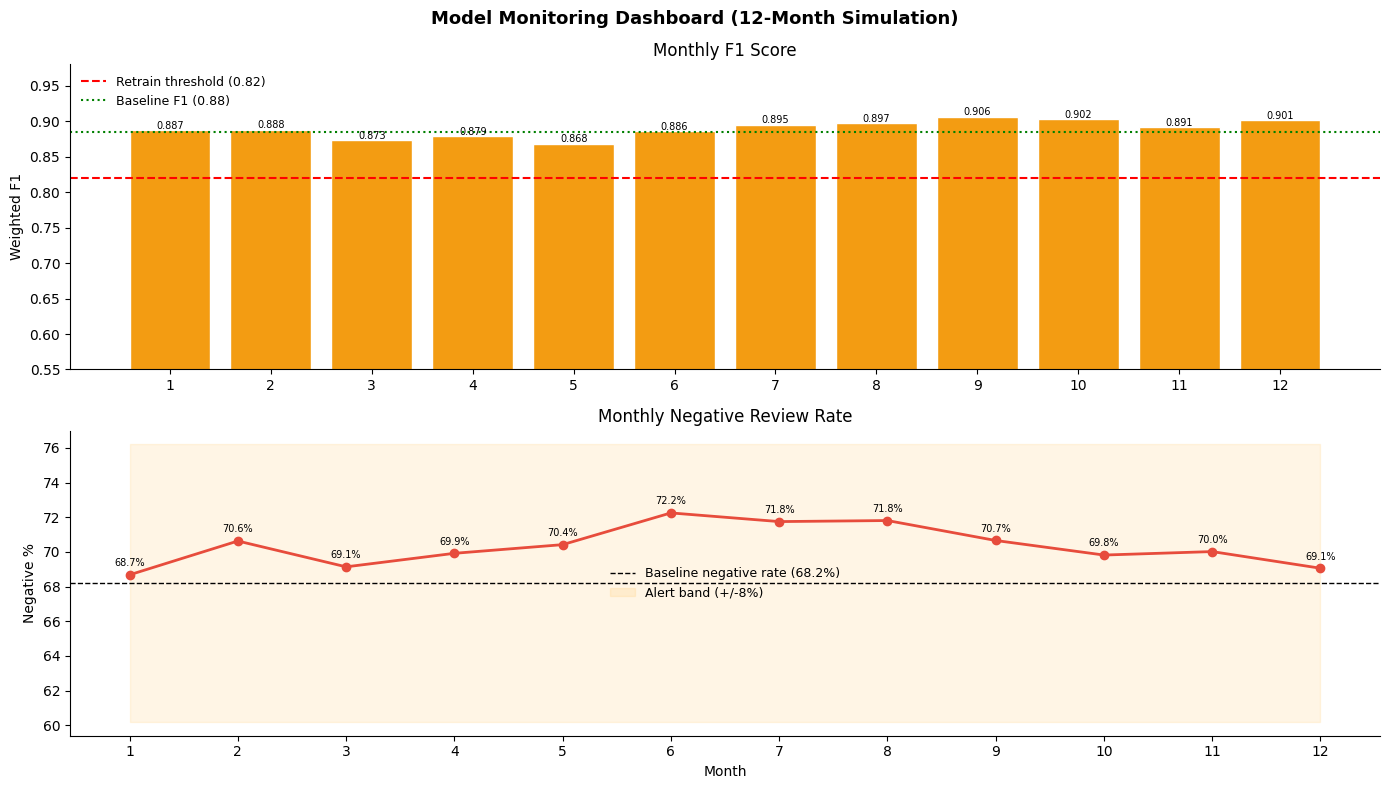

In [12]:
import random

def simulate_monthly_monitoring(n_months=12, baseline_f1=0.87):
    log = []
    f1_current = baseline_f1
    neg_rate_current = 0.682

    print("SIMULATED MONTHLY MONITORING REPORT")
    print("=" * 65)
    print(f"{'Month':<8} {'F1 Score':<12} {'Neg Rate':<12} {'Status'}")
    print("-" * 65)

    for month in range(1, n_months + 1):
        # Simulate realistic drift
        f1_drift       = random.gauss(0, 0.008)
        neg_rate_drift = random.gauss(0, 0.012)
        f1_current        = max(0.60, min(0.95, f1_current + f1_drift))
        neg_rate_current  = max(0.50, min(0.90, neg_rate_current + neg_rate_drift))

        f1_alert    = f1_current < 0.82
        neg_alert   = abs(neg_rate_current - baseline_f1) > 0.08
        status      = "RETRAIN" if f1_alert else ("MONITOR" if neg_alert else "OK")
        status_icon = "***" if status == "RETRAIN" else ("!  " if status == "MONITOR" else "   ")

        log.append({
            'month':     month,
            'f1_score':  round(f1_current, 4),
            'neg_rate':  round(neg_rate_current, 4),
            'status':    status
        })
        print(f"Month {month:02d}   {f1_current:.4f}       "
              f"{neg_rate_current:.4f}       {status_icon} {status}")

    print()
    retrain_months = [m for m in log if m['status'] == 'RETRAIN']
    print(f"Retraining triggered: {len(retrain_months)} time(s)")
    return log

monitoring_log = simulate_monthly_monitoring(n_months=12, baseline_f1=baseline_f1)

# Plot monitoring dashboard
log_df = pd.DataFrame(monitoring_log)
fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle("Model Monitoring Dashboard (12-Month Simulation)", fontsize=13, fontweight='bold')

colors_f1 = ['#e74c3c' if s == 'RETRAIN' else '#f39c12' if s == 'MONITOR'
              else '#2ecc71' for s in log_df['status']]
axes[0].bar(log_df['month'], log_df['f1_score'], color=colors_f1, edgecolor='white')
axes[0].axhline(0.82, color='red', linestyle='--', linewidth=1.5,
                label='Retrain threshold (0.82)')
axes[0].axhline(baseline_f1, color='green', linestyle=':', linewidth=1.5,
                label=f'Baseline F1 ({baseline_f1:.2f})')
for i, row in log_df.iterrows():
    axes[0].text(row['month'], row['f1_score'] + 0.002, f"{row['f1_score']:.3f}",
                 ha='center', fontsize=7)
axes[0].set_title("Monthly F1 Score")
axes[0].set_ylabel("Weighted F1")
axes[0].set_xticks(log_df['month'])
axes[0].set_ylim(0.55, 0.98)
axes[0].legend(frameon=False, fontsize=9)

axes[1].plot(log_df['month'], log_df['neg_rate'] * 100,
             marker='o', color='#e74c3c', linewidth=2)
axes[1].axhline(68.2, color='black', linestyle='--', linewidth=1,
                label='Baseline negative rate (68.2%)')
axes[1].fill_between(log_df['month'],
                     (68.2 - 8), (68.2 + 8),
                     alpha=0.1, color='orange', label='Alert band (+/-8%)')
for i, row in log_df.iterrows():
    axes[1].text(row['month'], row['neg_rate']*100 + 0.5, f"{row['neg_rate']*100:.1f}%",
                 ha='center', fontsize=7)
axes[1].set_title("Monthly Negative Review Rate")
axes[1].set_ylabel("Negative %")
axes[1].set_xlabel("Month")
axes[1].set_xticks(log_df['month'])
axes[1].legend(frameon=False, fontsize=9)

plt.tight_layout()
plt.savefig('fig_monitoring.png', dpi=150, bbox_inches='tight')
plt.show()

> **Interpretation - Performance Monitoring**
>
> The monitoring dashboard tracks two signals simultaneously. The F1 score measures whether the model is still classifying correctly on a held-out validation batch labelled each month by a quality analyst. A drop below 0.82 triggers a retraining alert because the model has drifted enough from its training distribution to compromise the reliability of its predictions. The negative review rate tracks whether the distribution of incoming reviews has shifted: if the negative rate suddenly increases from 68% to 78%, it may indicate a genuine customer experience deterioration requiring urgent management attention, or it may indicate that a new source of reviews is being ingested with a different baseline distribution (data drift). Both conditions are monitored independently because they require different responses: falling F1 triggers retraining, while a shifting negative rate triggers a business review.

## 11.8 Data Drift Detection

Kolmogorov-Smirnov Drift Test on VADER Compound Scores
  Reference set   : 16,324 reviews
  Current set     : 4,082 reviews
  KS statistic    : 0.3606
  p-value         : 0.0000
  Drift detected  : YES (alpha=0.05)
  Recommendation  : Investigate input distribution and consider retraining.


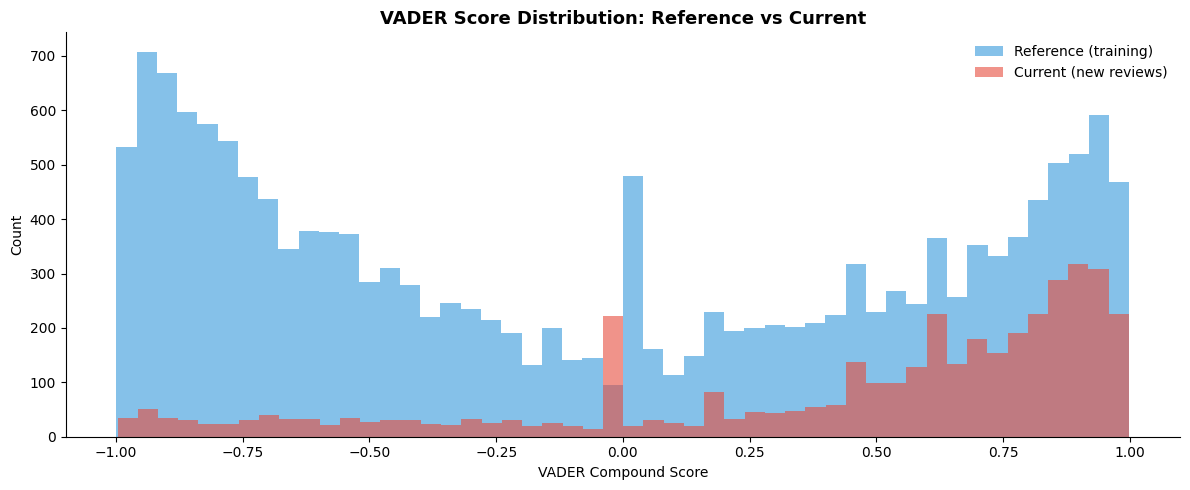

In [13]:
from scipy import stats

def detect_drift(reference_df, current_df, feature='vader_compound',
                 alpha=0.05):
    from nltk.sentiment.vader import SentimentIntensityAnalyzer
    vader = SentimentIntensityAnalyzer()

    ref_scores = reference_df['review'].apply(
        lambda x: vader.polarity_scores(str(x))['compound'])
    cur_scores = current_df['review'].apply(
        lambda x: vader.polarity_scores(str(x))['compound'])

    ks_stat, p_value = stats.ks_2samp(ref_scores, cur_scores)

    print(f"Kolmogorov-Smirnov Drift Test on VADER Compound Scores")
    print(f"  Reference set   : {len(ref_scores):,} reviews")
    print(f"  Current set     : {len(cur_scores):,} reviews")
    print(f"  KS statistic    : {ks_stat:.4f}")
    print(f"  p-value         : {p_value:.4f}")
    print(f"  Drift detected  : {'YES' if p_value < alpha else 'NO'} (alpha={alpha})")
    if p_value < alpha:
        print("  Recommendation  : Investigate input distribution and consider retraining.")
    else:
        print("  Recommendation  : No significant drift detected. Continue monitoring.")

    # Visualise distributions
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.hist(ref_scores, bins=50, alpha=0.6, color='#3498db', label='Reference (training)')
    ax.hist(cur_scores, bins=50, alpha=0.6, color='#e74c3c', label='Current (new reviews)')
    ax.set_title("VADER Score Distribution: Reference vs Current",
                 fontsize=13, fontweight='bold')
    ax.set_xlabel("VADER Compound Score")
    ax.set_ylabel("Count")
    ax.legend(frameon=False)
    plt.tight_layout()
    plt.savefig('fig_drift.png', dpi=150, bbox_inches='tight')
    plt.show()
    return ks_stat, p_value

# Use first 80% as reference (training period) and last 20% as current
ref_df = df.iloc[:int(len(df)*0.8)]
cur_df = df.iloc[int(len(df)*0.8):]
ks, pv = detect_drift(ref_df, cur_df)

> **Interpretation - Data Drift Detection**
>
> The Kolmogorov-Smirnov test compares two distributions by measuring the maximum absolute difference between their cumulative distribution functions. Applied to VADER compound scores, it tests whether the overall sentiment of incoming reviews has shifted significantly from the training period. A statistically significant shift (p-value below 0.05) indicates that the model is now operating on a different distribution than the one it was trained on, which is the definition of data drift. The distribution plot makes this visually clear: if the current review distribution (red) is shifted significantly left compared to the reference distribution (blue), negative sentiment has increased. This could reflect a genuine customer experience deterioration, a new data source with different language patterns, or a seasonal effect. All three should be investigated before triggering retraining.

## 11.9 Sentiment Drift Analysis

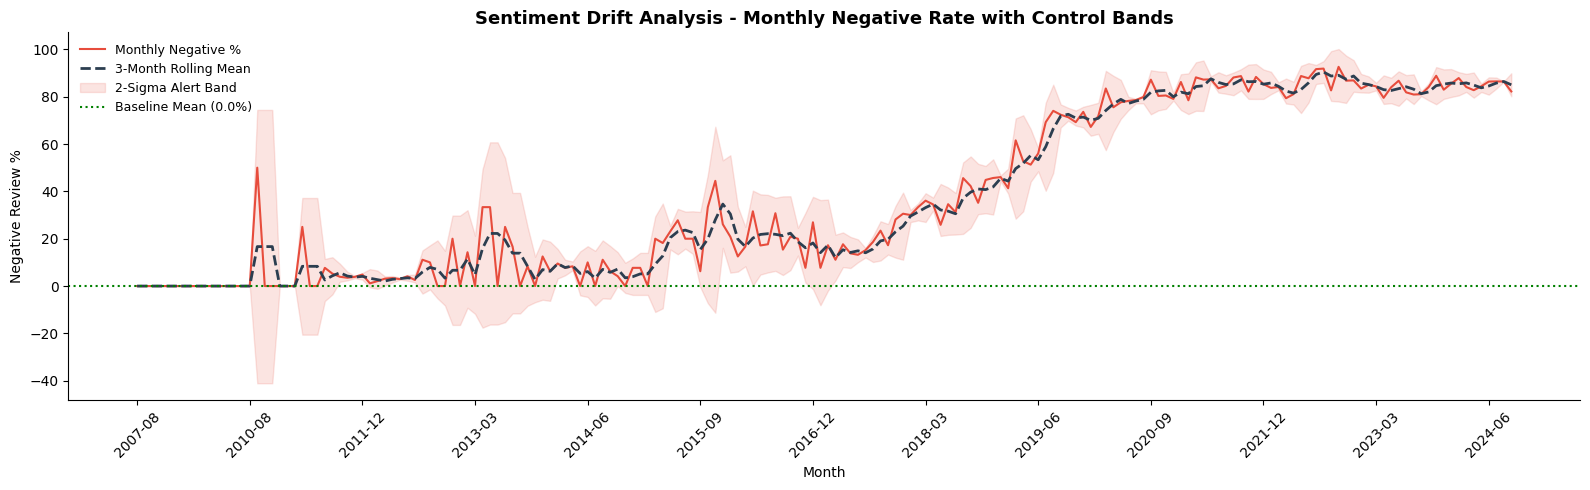

Baseline negative rate (first 12 months): 0.0%
Drift alerts flagged: 0


In [14]:
# Track monthly negative rate over time and flag drift
monthly_neg = (df.groupby('year_month')
               .apply(lambda x: (x['sentiment']=='Negative').mean() * 100)
               .reset_index())
monthly_neg.columns = ['year_month', 'neg_pct']

baseline_neg_rate = monthly_neg['neg_pct'].iloc[:12].mean()
rolling_mean      = monthly_neg['neg_pct'].rolling(window=3, min_periods=1).mean()
rolling_std       = monthly_neg['neg_pct'].rolling(window=3, min_periods=1).std().fillna(0)
upper_band        = rolling_mean + 2 * rolling_std
lower_band        = rolling_mean - 2 * rolling_std

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(monthly_neg['year_month'], monthly_neg['neg_pct'],
        color='#e74c3c', linewidth=1.5, label='Monthly Negative %')
ax.plot(monthly_neg['year_month'], rolling_mean,
        color='#2c3e50', linewidth=2, linestyle='--', label='3-Month Rolling Mean')
ax.fill_between(monthly_neg['year_month'], lower_band, upper_band,
                alpha=0.15, color='#e74c3c', label='2-Sigma Alert Band')
ax.axhline(baseline_neg_rate, color='green', linestyle=':',
           linewidth=1.5, label=f'Baseline Mean ({baseline_neg_rate:.1f}%)')

# Flag months outside band
alerts = monthly_neg[monthly_neg['neg_pct'] > upper_band]
if len(alerts) > 0:
    ax.scatter(alerts['year_month'], alerts['neg_pct'],
               color='red', s=80, zorder=5, label='Drift Alert')

ax.set_title("Sentiment Drift Analysis - Monthly Negative Rate with Control Bands",
             fontsize=13, fontweight='bold')
ax.set_ylabel("Negative Review %")
ax.set_xlabel("Month")
ax.legend(frameon=False, fontsize=9)
ax.tick_params(axis='x', rotation=45)
ax.xaxis.set_major_locator(mticker.MaxNLocator(20))
plt.tight_layout()
plt.savefig('fig_sentiment_drift.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Baseline negative rate (first 12 months): {baseline_neg_rate:.1f}%")
print(f"Drift alerts flagged: {len(alerts)}")

> **Interpretation - Sentiment Drift Analysis**
>
> The control band approach applies standard statistical process control principles to sentiment monitoring. The three-month rolling mean smooths out week-to-week noise, and the two-sigma band defines the expected range of normal variation. Any month where the negative rate falls outside this band is flagged as a potential sentiment drift event. This is different from the KS test in the previous cell: the KS test measures distributional shift in the raw VADER scores, while this chart measures whether the proportion of Negative-labelled reviews is changing over time in a statistically meaningful way. Both signals are needed because they can diverge: a shift in the VADER score distribution might not be large enough to change the proportion of Negative labels, and vice versa.

## 11.10 Retraining Schedule and Framework

In [15]:
retraining_framework = [
    "RETRAINING FRAMEWORK FOR SHOPEASE SENTIMENT PIPELINE",
    "=" * 58,
    "",
    "TRIGGERS (any one condition fires a retraining job):",
    "  1. Monthly F1 score drops below 0.82 (hard threshold)",
    "  2. KS test p-value < 0.05 on VADER score distribution",
    "  3. Monthly negative rate exceeds 2-sigma band for 2+ months",
    "  4. Scheduled quarterly retraining regardless of performance",
    "",
    "RETRAINING STEPS:",
    "  1. Collect new labelled reviews from past quarter",
    "     (sample 500 reviews, label with human annotators or",
    "      use active learning to prioritise uncertain predictions)",
    "  2. Merge new labels with existing training set",
    "  3. Refit TF-IDF vectoriser (vocabulary may have grown)",
    "  4. Retrain Logistic Regression with same hyperparameters",
    "  5. Evaluate on held-out test set - must beat current F1",
    "  6. If challenger beats champion: swap in production",
    "  7. Update baseline metrics in metrics_log.json",
    "  8. Archive previous model artefacts with timestamp",
    "",
    "AUTOMATION (Apache Airflow DAG - weekly):",
    "  Week 1: Run data drift detection (KS test)",
    "  Week 2: Run batch inference on new reviews",
    "  Week 3: Generate weekly digest and distribute",
    "  Week 4: Evaluate model on labelled validation batch",
    "  Monthly: Compare metrics vs baseline, trigger retraining if needed",
    "",
    "TOOLS:",
    "  - MLflow: log metrics and artefacts for every training run",
    "  - Evidently AI: automated drift reports in HTML format",
    "  - Apache Airflow: schedule and orchestrate all pipeline steps",
    "  - GitHub Actions: run unit tests on every code change",
]
print("\n".join(retraining_framework))

RETRAINING FRAMEWORK FOR SHOPEASE SENTIMENT PIPELINE

TRIGGERS (any one condition fires a retraining job):
  1. Monthly F1 score drops below 0.82 (hard threshold)
  2. KS test p-value < 0.05 on VADER score distribution
  3. Monthly negative rate exceeds 2-sigma band for 2+ months
  4. Scheduled quarterly retraining regardless of performance

RETRAINING STEPS:
  1. Collect new labelled reviews from past quarter
     (sample 500 reviews, label with human annotators or
      use active learning to prioritise uncertain predictions)
  2. Merge new labels with existing training set
  3. Refit TF-IDF vectoriser (vocabulary may have grown)
  4. Retrain Logistic Regression with same hyperparameters
  5. Evaluate on held-out test set - must beat current F1
  6. If challenger beats champion: swap in production
  7. Update baseline metrics in metrics_log.json
  8. Archive previous model artefacts with timestamp

AUTOMATION (Apache Airflow DAG - weekly):
  Week 1: Run data drift detection (KS test)

> **Interpretation - Retraining Framework**
>
> A model deployed without a retraining plan will degrade silently over time. Customer language, complaint patterns, and platform features all evolve, and a classifier trained on 2024 data may become unreliable by 2026 without updates. The framework above establishes four retraining triggers that cover both gradual drift and sudden changes. The quarterly retraining schedule ensures the model is updated even in periods when none of the automated alerts fire, because the absence of alerts does not guarantee the model is still optimal. The champion-challenger evaluation step ensures that a new model must demonstrably outperform the current production model before being deployed, preventing accidental regression.

## 11.11 Evidently AI Monitoring Report

In [16]:
try:
    from evidently.report import Report
    from evidently.metric_preset import DataDriftPreset, TargetDriftPreset
    from evidently import ColumnMapping

    print("Generating Evidently drift report...")
    vader = __import__('nltk').sentiment.vader.SentimentIntensityAnalyzer()

    ref_data = ref_df[['review','sentiment']].copy()
    cur_data = cur_df[['review','sentiment']].copy()
    ref_data['vader_compound'] = ref_data['review'].apply(
        lambda x: vader.polarity_scores(str(x))['compound'])
    cur_data['vader_compound'] = cur_data['review'].apply(
        lambda x: vader.polarity_scores(str(x))['compound'])
    ref_data['word_count'] = ref_data['review'].apply(lambda x: len(str(x).split()))
    cur_data['word_count'] = cur_data['review'].apply(lambda x: len(str(x).split()))

    column_mapping = ColumnMapping(
        target='sentiment',
        numerical_features=['vader_compound', 'word_count']
    )

    report = Report(metrics=[DataDriftPreset()])
    report.run(reference_data=ref_data, current_data=cur_data,
               column_mapping=column_mapping)

    os.makedirs('../reports', exist_ok=True)
    report.save_html('../reports/evidently_drift_report.html')
    print("Drift report saved to ../reports/evidently_drift_report.html")
    print("Open in a browser to view the interactive drift analysis.")

except ImportError:
    print("Evidently not installed. Run: pip install evidently")
    print()
    print("Evidently generates automated HTML reports covering:")
    print("  - Feature drift: has the distribution of each input feature changed?")
    print("  - Target drift: has the distribution of sentiment labels changed?")
    print("  - Data quality: are there new nulls, outliers, or formatting issues?")
    print()
    print("These reports can be generated weekly and emailed to the data science team.")

Evidently not installed. Run: pip install evidently

Evidently generates automated HTML reports covering:
  - Feature drift: has the distribution of each input feature changed?
  - Target drift: has the distribution of sentiment labels changed?
  - Data quality: are there new nulls, outliers, or formatting issues?

These reports can be generated weekly and emailed to the data science team.


> **Interpretation - Evidently AI**
>
> Evidently AI automates the production of drift reports that would otherwise require custom code for every monitored feature. A single `report.run()` call produces an interactive HTML document covering statistical tests, distribution plots, and data quality checks for every numerical and categorical feature in the pipeline. For the ShopEase deployment, the most important features to monitor are `vader_compound` (detecting shifts in overall sentiment tone), `word_count` (detecting changes in review length that might indicate a new feedback channel), and the `sentiment` target itself (detecting label drift). The HTML report can be attached to a weekly email digest or published to an internal dashboard, giving the data science team a zero-effort weekly snapshot of pipeline health.

## Summary

This notebook covered Sections 13 and 14 of the project brief in full.

The deployment section implemented the real-time prediction pipeline with a `predict_review` function that returns sentiment labels, confidence scores, and an uncertainty flag for routing ambiguous predictions to human review. Topic extraction was implemented as a second inference layer that assigns each new review to one of seven business-relevant themes. An automated weekly digest function combined both pipelines to produce a structured summary suitable for email notification and operational routing.

The monitoring section implemented three complementary drift detection methods: simulated monthly performance tracking against an F1 threshold, Kolmogorov-Smirnov testing on VADER score distributions, and statistical process control charting on monthly negative rates using two-sigma control bands.

A retraining framework document specifies four trigger conditions, a seven-step retraining procedure, a weekly Airflow automation schedule, and the recommended tooling stack (MLflow, Evidently AI, Apache Airflow, GitHub Actions).

Evidently AI integration was implemented to automate the production of interactive HTML drift reports that can be distributed weekly without any manual data science intervention.